In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read
from tqdm import tqdm
import torch
import torch.nn as nn

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
DATA_PATH = r"D:\Seismic_Monitoring_AI\data\raw"
print(os.listdir(DATA_PATH))

['dischma_data']


In [4]:
for root, dirs, files in os.walk(DATA_PATH):
    print(root)
    print(files[:5])

D:\Seismic_Monitoring_AI\data\raw
[]
D:\Seismic_Monitoring_AI\data\raw\dischma_data
[]
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data
['labels.csv']
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21
[]
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS
['DSMA.CS.EHZ_20210113_0459-20210113_0505.mseed', 'DSMA.CS.EHZ_20210113_0829-20210113_0833.mseed', 'DSMA.CS.EHZ_20210113_0900-20210113_0921.mseed', 'DSMA.CS.EHZ_20210113_0942-20210113_0948.mseed', 'DSMA.CS.EHZ_20210113_1215-20210113_1219.mseed']
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CT
['DSMA.CT.EHE_20210113_0459-20210113_0505.mseed', 'DSMA.CT.EHE_20210113_0829-20210113_0833.mseed', 'DSMA.CT.EHE_20210113_0900-20210113_0921.mseed', 'DSMA.CT.EHE_20210113_0942-20210113_0948.mseed', 'DSMA.CT.EHE_20210113_1215-20210113_1219.mseed']
D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\NE
['DSMA.NE.EHZ_20210113_0459-202101

In [5]:
labels_path = r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\labels.csv"
df = pd.read_csv(labels_path)
print(df.head())
print(df.columns)
print(df.shape)
print(df["label"].value_counts())

   Unnamed: 0       Event_id                    starttime   initial_time  \
0           0  20210113_0459  2021-01-13T04:59:00.000000Z   14786.193554   
1           1  20210113_0829  2021-01-13T08:29:00.000000Z   10770.965059   
2           2  20210113_0900  2021-01-13T09:00:00.000000Z  218009.166918   
3           3  20210113_0942  2021-01-13T09:42:00.000000Z   16191.582307   
4           4  20210113_1215  2021-01-13T12:15:00.000000Z   17727.639386   

        end_time    duration  label  av_score  eq_score  
0   51642.513601  184.281600      0       0.0       0.0  
1   19390.682744   43.098588      0       0.0       0.0  
2  229322.546380   56.566897      0       0.0       0.0  
3   32353.552966   80.809853      0       0.0       0.0  
4   25223.046069   37.477033      0       0.5       0.0  
Index(['Unnamed: 0', 'Event_id', 'starttime', 'initial_time', 'end_time',
       'duration', 'label', 'av_score', 'eq_score'],
      dtype='str')
(926, 9)
label
0    657
2    185
1     84
Name: c

1 Trace(s) in Stream:
XP.DSMA.CS.EHZ | 2021-01-13T04:59:00.000000Z - 2021-01-13T05:05:00.000000Z | 200.0 Hz, 72001 samples
Sampling rate: 200.0
Number of samples: 72001


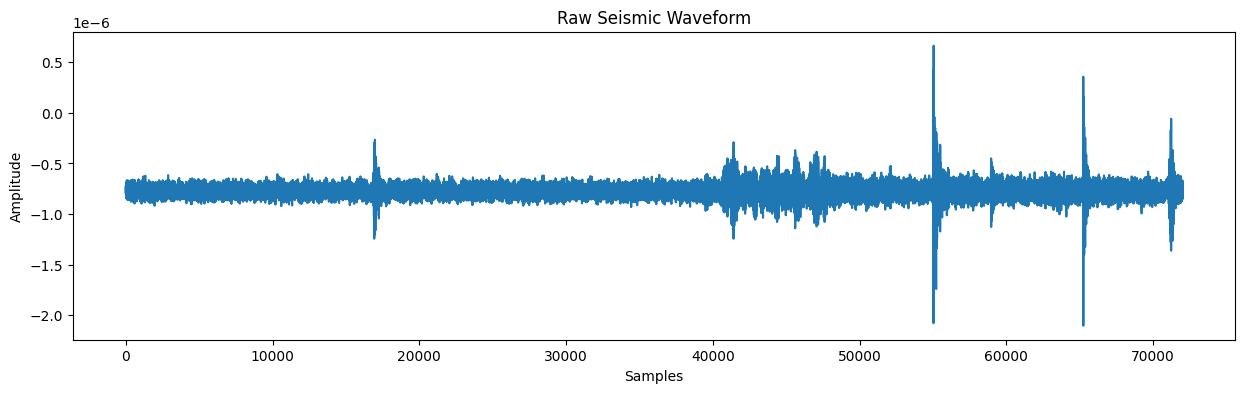

In [6]:
file_path = r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210113_0459-20210113_0505.mseed"
st = read(file_path)
tr = st[0]
print(st)
print("Sampling rate:", tr.stats.sampling_rate)
print("Number of samples:", len(tr.data))

plt.figure(figsize=(15,4))
plt.plot(tr.data)
plt.title("Raw Seismic Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [7]:
print(df.groupby("label")["duration"].describe())
print(df["Event_id"].head())

       count       mean        std        min        25%        50%  \
label                                                                 
0      657.0  45.054273  36.397998   4.508956  26.233923  37.769823   
1       84.0  48.573400  18.641466  16.044855  36.605985  42.483731   
2      185.0  68.343992  46.594812   6.558481  37.477033  54.575930   

             75%         max  
label                         
0      51.882268  514.577236  
1      57.884449  112.079753  
2      86.958429  262.046445  
0    20210113_0459
1    20210113_0829
2    20210113_0900
3    20210113_0942
4    20210113_1215
Name: Event_id, dtype: str


# Dataset generation

In [8]:
DATA_ROOT = r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data"
WINDOW_SECONDS = 10
SAMPLING_RATE = 200
WINDOW_SIZE = WINDOW_SECONDS * SAMPLING_RATE

def find_file(event_id, station="CS"):
    seasons = ["season_2020_21", "season_2021_22"]
    for season in seasons:
        folder = os.path.join(DATA_ROOT, season, station)
        for file in os.listdir(folder):
            if event_id in file:
                return os.path.join(folder, file)
    return None

def extract_window(signal, start_pick, end_pick, window_size=2000):
    center = int((start_pick + end_pick) / 2)
    left = center - window_size // 2
    right = center + window_size // 2
    if left < 0:
        left = 0
        right = window_size
    if right > len(signal):
        right = len(signal)
        left = len(signal) - window_size
    return signal[left:right]


In [9]:
# Create a balanced-ish augmented dataset from one station (CS)
X = []
y = []
OFFSETS = [-400, -200, 0, 200, 400]

for _, row in tqdm(df.iterrows(), total=len(df)):
    event_id = row["Event_id"]
    file_path = find_file(event_id, station="CS")
    if file_path is None:
        continue

    tr = read(file_path)[0]
    signal = tr.data.astype(np.float32)

    start_pick = int(row["initial_time"])
    end_pick = int(row["end_time"])
    center = int((start_pick + end_pick) / 2)

    for offset in OFFSETS:
        new_center = center + offset
        left = new_center - WINDOW_SIZE // 2
        right = new_center + WINDOW_SIZE // 2
        if left < 0 or right > len(signal):
            continue

        window = signal[left:right].copy()

        # normalize per window here
        window_mean = window.mean()
        window_std = window.std() + 1e-8
        window = (window - window_mean) / window_std

        X.append(window.astype(np.float32))
        y.append(int(row["label"]))

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print(X.shape)
print(y.shape)
print("min/max/std:", X.min(), X.max(), X.std())


100%|██████████| 926/926 [00:06<00:00, 140.59it/s]

(4605, 2000)
(4605,)
min/max/std: -16.823315 18.967665 0.8415163


In [10]:
unique, counts = np.unique(y, return_counts=True)
for c, n in zip(unique, counts):
    print(c, n)

0 3260
1 420
2 925


In [11]:
# IMPORTANT: add channel dimension after the windows are created
X = X[:, np.newaxis, :]

print(X.shape)
print(X[0, 0, :10])

(4605, 1, 2000)
[ 0.10988244 -0.0103393  -0.9721144  -1.2726693  -0.13056105  1.3121021
  1.612657    0.831214    0.04977102 -0.5513377 ]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3684, 1, 2000)
(921, 1, 2000)


In [13]:
from torch.utils.data import Dataset, DataLoader

class SeismicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SeismicDataset(X_train, y_train)
test_dataset = SeismicDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
class SeismicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SeismicCNN().to(device)
print(model)

SeismicCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_f

In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
##weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
##weights = torch.tensor(weights, dtype=torch.float32).to(device)
##print(weights)

##criterion = nn.CrossEntropyLoss(weight=weights)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [17]:
from tqdm import tqdm

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader)
    for X_batch, y_batch in loop:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        total += y_batch.size(0)
        correct += (preds == y_batch).sum().item()

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} Acc={correct/total:.4f}")


100%|██████████| 58/58 [00:01<00:00, 47.87it/s]


Epoch 1: Loss=0.7462 Acc=0.7332


100%|██████████| 58/58 [00:00<00:00, 90.48it/s]


Epoch 2: Loss=0.6289 Acc=0.7611


100%|██████████| 58/58 [00:00<00:00, 91.86it/s]


...

Epoch 18: Loss=0.4988 Acc=0.8002


100%|██████████| 58/58 [00:00<00:00, 91.35it/s]


Epoch 19: Loss=0.4923 Acc=0.8040


100%|██████████| 58/58 [00:00<00:00, 92.53it/s]

Epoch 20: Loss=0.4840 Acc=0.8056


In [27]:
torch.save(
    model.state_dict(),
    r"D:\Seismic_Monitoring_AI\models\best_seismic_model_v3.pth"
)

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=["Noise", "Avalanche", "Earthquake"]))


Test Accuracy: 0.8002171552660152
              precision    recall  f1-score   support

       Noise       0.81      0.95      0.87       652
   Avalanche       0.88      0.44      0.59        84
  Earthquake       0.72      0.45      0.55       185

    accuracy                           0.80       921
   macro avg       0.80      0.61      0.67       921
weighted avg       0.80      0.80      0.78       921



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[617   3  32]
 [ 47  37   0]
 [100   2  83]]
